# **OPTIMASI LINEUP KONSER MUSIK MENGGUNAKAN GENETIC ALGORITHM**
### **Studi Kasus: Jazz Prambanan Festival 2026**

**Tujuan**

Menentukan urutan tampil artis yang optimal berdasarkan:
- Energy Flow
- Popularity Placement
- Headliner Constraint

menggunakan Genetic Algorithm (GA).

---


In [2]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

random.seed(42)
np.random.seed(42)

# **DATA PRE-PROCESSING**

Tahapan:

1. Data Cleaning
2. Data Validation
3. Data Transformation
4. Data Partitioning per Day

## 1. Clean Dataset

In [3]:
def clean_lineup_data(sheet_url):

    try:
        sheet_id = sheet_url.split('/d/')[1].split('/')[0]
        csv_url = (
            f'https://docs.google.com/spreadsheets/d/'
            f'{sheet_id}/export?format=csv'
        )

    except IndexError:
        raise ValueError(
            "Format URL Google Sheets tidak valid."
        )
    df = pd.read_csv(csv_url)
    df = df.dropna()
    col_listeners = 'Monthly_listeners (Mei 2026)'

    if df[col_listeners].dtype == 'object':
        df[col_listeners] = (
            df[col_listeners]
            .str.replace(',', '')
            .astype(int)
        )
    df['Artist_name'] = (
        df['Artist_name']
        .str.lower()
    )
    df['Genre'] = (
        df['Genre']
        .str.lower()
    )

    return df

## 2. Data Validation

In [4]:
def validate_and_transform(df):

    numeric_cols = [
        'Popularity_score',
        'Energy',
        'Tempo',
        'Is_headliner'
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )
    df = df.drop_duplicates(
        subset=[
            'Artist_name',
            'Day'
        ],
        keep='first'
    )

    return df.dropna()

## 3. Data Partition

In [5]:
def partition_data_by_day(df):
    days = sorted(df['Day'].unique())
    lineup_per_day = {
        day:
        df[df['Day'] == day]
        .reset_index(drop=True)

        for day in days
    }

    return lineup_per_day

## 4. Load Dataset


In [6]:
url_dataset = (
    "https://docs.google.com/spreadsheets/"
    "d/10em009qM5HAgczrtVNAQKs5YG1YA2fgn8RQBLcmjGKs/"
    "edit?usp=sharing"
)

df_cleaned = clean_lineup_data(
    url_dataset
)

df_validated = validate_and_transform(
    df_cleaned
)

display(df_validated.head())

print(
    f"Total Data: {len(df_validated)}"
)

,Artist_name,Day,Genre,Popularity_score,Monthly_listeners (Mei 2026),Energy,Tempo,Is_headliner
0,ali,1,indonesian rock,0.007242,128110,5,102.333333,0
1,barasuara,1,indie rock,0.379183,5811614,4,93.000000,0
2,idgitaf,1,indonesian pop,0.922344,14111488,7,141.333333,0
3,lomba sihir,1,alternative pop,0.132689,2045030,4,93.666667,0
4,michael learns to rock,1,soft rock,0.235764,3620074,7,137.333333,1


Total Data: 31


## 5.  Dataset Info


In [7]:
print(df_validated.info())
display(
    df_validated.describe()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Artist_name                   31 non-null     object 
 1   Day                           31 non-null     int64  
 2   Genre                         31 non-null     object 
 3   Popularity_score              31 non-null     float64
 4   Monthly_listeners (Mei 2026)  31 non-null     int64  
 5   Energy                        31 non-null     int64  
 6   Tempo                         31 non-null     float64
 7   Is_headliner                  31 non-null     int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 2.1+ KB
None


,Day,Popularity_score,Monthly_listeners (Mei 2026),Energy,Tempo,Is_headliner
count,31.000000,31.000000,3.100000e+01,31.000000,31.000000,31.000000
mean,1.935484,0.219971,3.378751e+06,5.806452,119.333333,0.096774
std,0.813858,0.296448,4.529918e+06,1.301777,18.083346,0.300537
min,1.000000,0.000000,1.744700e+04,3.000000,83.000000,0.000000
25%,1.000000,0.006934,1.234000e+05,5.000000,106.000000,0.000000
50%,2.000000,0.074817,1.160702e+06,6.000000,119.666667,0.000000
75%,3.000000,0.375356,5.753140e+06,7.000000,133.500000,0.000000
max,3.000000,1.000000,1.529812e+07,8.000000,154.666667,1.000000


# **EXPLORATORY DATA ANALYSYS (EDA)**

## 1. Energy Distribution

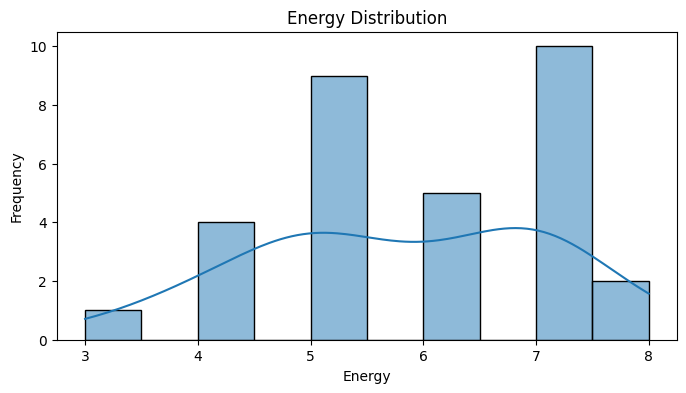

In [8]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_validated['Energy'],
    bins=10,
    kde=True
)

plt.title(
    "Energy Distribution"
)
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.show()

## 2. Popularity Distribution

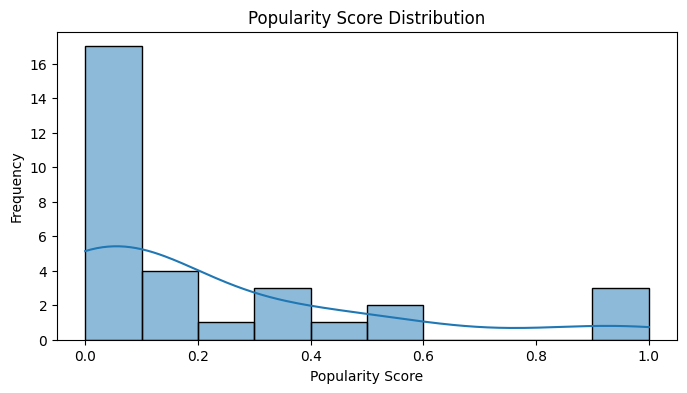

In [9]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_validated['Popularity_score'],
    bins=10,
    kde=True
)

plt.title(
    "Popularity Score Distribution"
)
plt.xlabel(
    "Popularity Score"
)
plt.ylabel(
    "Frequency"
)
plt.show()

# **RANCANGAN ALGORITMA GENETIKA**

## **1. Representasi Solusi**
**Metode**: Permutation-Based Representation

In [10]:
def create_chromosome(num_artists):
    chromosome = np.random.permutation(
        num_artists
    )

    return chromosome

## **2. Inisialisasi Populasi**
**Metode**: Random Permutation

In [11]:
def initialize_population(
    pop_size,
    num_artists
):

    return [
        np.random.permutation(
            num_artists
        )

        for _ in range(pop_size)
    ]

## **3. Fitness Function**
Fitness dihitung berdasarkan:

1. Energy Flow Score
2. Popularity Placement Score
3. Headliner Constraint

In [12]:
def calculate_fitness(
    chromosome,
    df_day,
    w1=1.0,
    w2=5.0,
    w3=2.0
):

    n = len(chromosome)
    lineup = df_day.iloc[
        chromosome
    ]

    energies = (
        lineup['Energy']
        .values
    )

    popularities = (
        lineup['Popularity_score']
        .values
    )

    headliners = (
        lineup['Is_headliner']
        .values
    )

    energy_score = 0
    popularity_score = 0
    headliner_score = 0

    # ==================================
    # ENERGY FLOW
    # ==================================

    for i in range(n - 1):
        diff = (
            energies[i + 1]
            - energies[i]
        )
        if diff >= 0:
            energy_score += (
                diff + 1
            )
        else:
            energy_score += (
                diff * 2
            )

    # ==================================
    # POPULARITY PLACEMENT
    # ==================================

    popularity_norm = (
        popularities
        / popularities.max()
    )

    for i in range(n):
        popularity_score += (
            popularity_norm[i]
            * (i + 1)
        )

    # ==================================
    # HEADLINER CONSTRAINT
    # ==================================

    if headliners[-1] == 1:
        headliner_score = 50
    else:
        headliner_score = -50
    fitness = (
        w1 * energy_score +
        w2 * popularity_score +
        w3 * headliner_score
    )

    return fitness

##**4. Seleksi Parent**
**Metode**: Tournament Selection

In [13]:
def tournament_selection(

    population,
    fitness_scores,
    k=3

):

    selected_indices = random.sample(
        range(len(population)),
        k
    )

    best_idx = selected_indices[0]
    best_fitness = fitness_scores[
        best_idx
    ]

    for idx in selected_indices[1:]:
        if (
            fitness_scores[idx]
            > best_fitness
        ):

            best_idx = idx
            best_fitness = (
                fitness_scores[idx]
            )

    return population[
        best_idx
    ]

## **5. Crossover**
**Metode**: Order Crossover

In [14]:
def order_crossover(
    parent1,
    parent2

):

    size = len(parent1)
    start, end = sorted(
        random.sample(
            range(size),
            2
        )
    )

    child = np.full(
        size,
        -1
    )

    child[
        start:end+1
    ] = parent1[
        start:end+1
    ]

    p2_idx = 0

    for i in range(size):
        if child[i] == -1:
            while (
                parent2[p2_idx]
                in child
            ):
                p2_idx += 1
            child[i] = (
                parent2[p2_idx]
            )

    return child

## **6. Mutasi**
**Metode**: Swap Mutation

In [15]:
def swap_mutation(
    chromosome,
    mutation_rate
):

    if (
        random.random()
        < mutation_rate
    ):

        idx1, idx2 = random.sample(
            range(
                len(chromosome)
            ),
            2
        )

        chromosome[idx1], chromosome[idx2] = (
            chromosome[idx2],
            chromosome[idx1]
        )

    return chromosome

## **7. Update Generasi (Evolusi)**
**Metode**: Elitism

Proses evolusi menggunakan:
1. Tournament Selection
2. Order Crossover
3. Swap Mutation
4. Elitism

In [16]:
def run_evolution(
    df_day,
    params
):

    num_artists = len(df_day)
    population = initialize_population(
        params['population_size'],
        num_artists
    )

    best_overall_chromosome = None
    best_overall_fitness = float('-inf')
    fitness_history = []
    avg_fitness_history = []

    for generation in range(
        params['max_generations']
    ):

        fitness_scores = [
            calculate_fitness(
                chrom,
                df_day
            )
            for chrom in population
        ]
        current_best_idx = np.argmax(
            fitness_scores
        )
        current_best_fitness = (
            fitness_scores[
                current_best_idx
            ]
        )
        current_avg_fitness = (
            np.mean(
                fitness_scores
            )
        )

        fitness_history.append(
            current_best_fitness
        )
        avg_fitness_history.append(
            current_avg_fitness
        )
        if (
            current_best_fitness
            >
            best_overall_fitness
        ):

            best_overall_fitness = (
                current_best_fitness
            )
            best_overall_chromosome = (
                population[
                    current_best_idx
                ].copy()
            )

        new_population = []

        # ELITISM
        new_population.append(
            best_overall_chromosome.copy()
        )

        while len(new_population) < (
            params['population_size']
        ):

            parent1 = (
                tournament_selection(
                    population,
                    fitness_scores
                )
            )

            parent2 = (
                tournament_selection(
                    population,
                    fitness_scores
                )
            )
            if random.random() < (
                params['crossover_rate']
            ):

                child = order_crossover(
                    parent1,
                    parent2
                )

            else:
                child = parent1.copy()
            child = swap_mutation(
                child,
                params['mutation_rate']
            )

            new_population.append(
                child
            )

        population = new_population
    return (
        best_overall_chromosome,
        best_overall_fitness,
        fitness_history,
        avg_fitness_history
    )

## **8. Parameter Algoritma Genetika**

| Parameter       | Nilai | Alasan                                                                                  |
| --------------- | ----- | --------------------------------------------------------------------------------------- |
| Population Size | 100   | Dipilih agar variasi solusi yang dihasilkan cukup banyak.                               |
| Max Generations | 300   | Digunakan agar proses pencarian solusi dapat berjalan lebih optimal.                    |
| Crossover Rate  | 0.8   | Memungkinkan proses pertukaran gen terjadi lebih sering untuk menghasilkan solusi baru. |
| Mutation Rate   | 0.1   | Menjaga keberagaman solusi dan mengurangi kemungkinan terjebak pada solusi lokal.       |


In [17]:
ga_parameters = {
    "population_size": 100,
    "max_generations": 300,
    "crossover_rate": 0.8,
    "mutation_rate": 0.1
}

In [18]:
# =====================================================
# CONSTRAINT SATISFACTION
# =====================================================

def evaluate_constraints(
    chromosome,
    df_day
):

    lineup = df_day.iloc[
        chromosome
    ]
    total_constraints = 3
    satisfied = 0

    if (
        lineup['Artist_name']
        .nunique()
        ==
        len(lineup)
    ):
        satisfied += 1

    if (
        len(lineup)
        ==
        len(df_day)
    ):
        satisfied += 1

    if (
        lineup.iloc[-1]
        ['Is_headliner']
        == 1
    ):
        satisfied += 1

    return (
        satisfied
        /
        total_constraints
    ) * 100


# =====================================================
# HEADLINER VALIDATION
# =====================================================

def headliner_accuracy(
    chromosome,
    df_day
):

    lineup = df_day.iloc[
        chromosome
    ]
    if (
        lineup.iloc[-1]
        ['Is_headliner']
        == 1
    ):

        return 100

    return 0


# =====================================================
# LINEUP SUMMARY
# =====================================================

def create_lineup_summary(
    chromosome,
    df_day
):

    lineup = (
        df_day
        .iloc[
            chromosome
        ]
        .copy()
    )

    lineup[
        'Performance_Order'
    ] = range(
        1,
        len(lineup)+1
    )

    return lineup[
        [
            'Performance_Order',
            'Artist_name',
            'Genre',
            'Popularity_score',
            'Energy',
            'Tempo',
            'Is_headliner'
        ]
    ]


# =====================================================
# DASHBOARD SUMMARY
# =====================================================

def lineup_statistics(
    lineup
):

    return {

        "Total Artist":
        len(lineup),

        "Average Energy":
        round(
            lineup[
                'Energy'
            ].mean(),
            2
        ),

        "Average Popularity":
        round(
            lineup[
                'Popularity_score'
            ].mean(),
            2
        ),

        "Headliner":
        lineup.iloc[-1][
            'Artist_name'
        ]
    }

# **Fungsi Evaluasi**

In [18]:
# =====================================================
# LINEUP SUMMARY
# =====================================================

def create_lineup_summary(
    chromosome,
    df_day
):

    lineup = (
        df_day
        .iloc[
            chromosome
        ]
        .copy()
    )

    lineup[
        'Performance_Order'
    ] = range(
        1,
        len(lineup)+1
    )

    return lineup[
        [
            'Performance_Order',
            'Artist_name',
            'Genre',
            'Popularity_score',
            'Energy',
            'Tempo',
            'Is_headliner'
        ]
    ]


# =====================================================
# CONSTRAINT SATISFACTION
# =====================================================

def evaluate_constraints(
    chromosome,
    df_day
):

    lineup = df_day.iloc[
        chromosome
    ]
    total_constraints = 3
    satisfied = 0

    if (
        lineup['Artist_name']
        .nunique()
        ==
        len(lineup)
    ):
        satisfied += 1

    if (
        len(lineup)
        ==
        len(df_day)
    ):
        satisfied += 1

    if (
        lineup.iloc[-1]
        ['Is_headliner']
        == 1
    ):
        satisfied += 1

    return (
        satisfied
        /
        total_constraints
    ) * 100


# =====================================================
# HEADLINER VALIDATION
# =====================================================

def headliner_accuracy(
    chromosome,
    df_day
):

    lineup = df_day.iloc[
        chromosome
    ]
    if (
        lineup.iloc[-1]
        ['Is_headliner']
        == 1
    ):

        return 100

    return 0


# =====================================================
# DASHBOARD SUMMARY
# =====================================================

def lineup_statistics(
    lineup
):

    return {

        "Total Artist":
        len(lineup),

        "Average Energy":
        round(
            lineup[
                'Energy'
            ].mean(),
            2
        ),

        "Average Popularity":
        round(
            lineup[
                'Popularity_score'
            ].mean(),
            2
        ),

        "Headliner":
        lineup.iloc[-1][
            'Artist_name'
        ]
    }


# **Fungsi Visualisasi**

In [19]:
# =====================================================
# FITNESS CONVERGENCE
# =====================================================

def plot_convergence(
    best_history,
    avg_history,
    day
):

    plt.figure(
        figsize=(10,5)
    )

    plt.plot(
        best_history,
        label='Best Fitness'
    )

    plt.plot(
        avg_history,
        label='Average Fitness'
    )

    plt.title(
        f'Fitness Convergence Day {day}'
    )

    plt.xlabel(
        'Generation'
    )

    plt.ylabel(
        'Fitness'
    )

    plt.legend()

    plt.grid(True)

    plt.show()


# =====================================================
# ENERGY FLOW
# =====================================================

def plot_energy_flow(
    chromosome,
    df_day,
    day
):

    lineup = df_day.iloc[
        chromosome
    ]

    plt.figure(
        figsize=(10,5)
    )

    plt.plot(
        lineup['Energy'].values,
        marker='o'
    )

    plt.title(
        f'Energy Flow Day {day}'
    )

    plt.xlabel(
        'Performance Order'
    )

    plt.ylabel(
        'Energy'
    )

    plt.grid(True)

    plt.show()


# =====================================================
# POPULARITY PLACEMENT
# =====================================================

def plot_popularity_flow(
    chromosome,
    df_day,
    day
):

    lineup = df_day.iloc[
        chromosome
    ]

    plt.figure(
        figsize=(12,5)
    )

    plt.bar(
        lineup[
            'Artist_name'
        ],
        lineup[
            'Popularity_score'
        ]
    )

    plt.xticks(
        rotation=90
    )

    plt.title(
        f'Popularity Placement Day {day}'
    )

    plt.ylabel(
        'Popularity Score'
    )

    plt.tight_layout()
    plt.show()

# **MAIN EXECUTION**

In [20]:
# ==========================================
# PARTITION DATA
# ==========================================

lineup_partitions = partition_data_by_day(
    df_validated
)

# ==========================================
# RUN GENETIC ALGORITHM
# ==========================================
all_day_results = {}

for day, df_day in lineup_partitions.items():

    (
        best_chrom,
        best_fit,
        fitness_history,
        avg_history
    ) = run_evolution(
        df_day,
        ga_parameters
    )

    lineup_summary = create_lineup_summary(
        best_chrom,
        df_day
    )

    all_day_results[day] = {
        "df_day": df_day,
        "best_chrom": best_chrom,
        "best_fit": best_fit,
        "fitness_history": fitness_history,
        "avg_history": avg_history,
        "lineup_summary": lineup_summary
    }

print("Optimasi seluruh hari selesai.")
print(f"Total hari diproses: {len(all_day_results)}")


Optimasi seluruh hari selesai.
Total hari diproses: 3


## 1. Hasil Line Up Per Hari

In [22]:
# ==========================================
# LINEUP RESULT
# ==========================================

for day, result in all_day_results.items():

    print("\n")
    print("=" * 70)
    print(f"DAY {day}")
    print("=" * 70)

    display(result["lineup_summary"])



DAY 1


,Performance_Order,Artist_name,Genre,Popularity_score,Energy,Tempo,Is_headliner
0,1,ali,indonesian rock,0.007242,5,102.333333,0
5,2,mocca,indie pop,0.012551,7,130.000000,0
9,3,the panturas playing jazz,surf rock,0.065851,5,109.000000,0
10,4,xdinary heroes,k-rock,0.067962,5,107.000000,0
8,5,salma salsabil playing jazz,pop,0.167278,5,111.333333,0
3,6,lomba sihir,alternative pop,0.132689,4,93.666667,0
1,7,barasuara,indie rock,0.379183,4,93.000000,0
7,8,rony parulian,pop,0.379028,7,132.666667,0
6,9,perunggu playing jazz,indie rock,0.578344,7,134.333333,0
2,10,idgitaf,indonesian pop,0.922344,7,141.333333,0




DAY 2


,Performance_Order,Artist_name,Genre,Popularity_score,Energy,Tempo,Is_headliner
9,1,societeit de harmonie,orchestra,0.001626,4,97.666667,0
4,2,karimata,jazz fusion,0.000033,5,105.000000,0
1,3,fryda lucyana,pop jazz,0.001699,5,107.666667,0
7,4,modulus,electronic jazz,0.000000,6,119.666667,0
6,5,margie segers,jazz,0.000699,7,135.666667,0
0,6,dinda ghania,pop,0.006626,7,134.666667,0
2,7,joey alexander,jazz,0.006293,5,111.666667,0
5,8,letto,alternative rock,0.173978,5,101.000000,0
3,9,kahitna,pop jazz,0.464450,7,131.666667,0
10,10,yovie & nuno,pop,0.552267,7,139.333333,0




DAY 3


,Performance_Order,Artist_name,Genre,Popularity_score,Energy,Tempo,Is_headliner
2,1,jikustik,pop rock,0.074817,5,112.000000,0
5,2,nonaria,indonesian jazz,0.006121,6,129.000000,0
1,3,fariz rm,jazz pop,0.008809,6,115.666667,0
6,4,rio febrian 'a night on broadway',pop,0.024485,6,124.333333,0
3,5,kla project,pop rock,0.024626,6,122.666667,0
0,6,ari lasso,rock,0.371684,8,154.666667,0
4,7,maliq d'essentials,jazz fusion,0.159517,4,99.666667,0
7,8,tulus,jazz pop,0.908098,3,83.000000,0
8,9,the rose,k-rock,0.085033,7,132.333333,1


## 2. Best Fitness per Hari

In [23]:
# ==========================================
# BEST FITNESS
# ==========================================

for day, result in all_day_results.items():

    print(f"\nDAY {day}")
    print("BEST FITNESS")
    print(
        round(result["best_fit"], 2)
    )


DAY 1
BEST FITNESS
241.67

DAY 2
BEST FITNESS
221.94

DAY 3
BEST FITNESS
167.48


## 3. Constraint Satisfaction

In [24]:
# ==========================================
# CONSTRAINT SATISFACTION
# ==========================================

for day, result in all_day_results.items():

    constraint_rate = (
        evaluate_constraints(
            result["best_chrom"],
            result["df_day"]
        )
    )

    print(f"\nDAY {day}")
    print("CONSTRAINT SATISFACTION")
    print(
        f"{constraint_rate:.2f}%"
    )


DAY 1
CONSTRAINT SATISFACTION
100.00%

DAY 2
CONSTRAINT SATISFACTION
100.00%

DAY 3
CONSTRAINT SATISFACTION
100.00%


## 4. Headliner Validation

In [25]:
# ==========================================
# HEADLINER VALIDATION
# ==========================================

for day, result in all_day_results.items():

    accuracy = (
        headliner_accuracy(
            result["best_chrom"],
            result["df_day"]
        )
    )

    print(f"\nDAY {day}")
    print("HEADLINER VALIDATION")
    print(
        f"{accuracy}%"
    )



DAY 1
HEADLINER VALIDATION
100%

DAY 2
HEADLINER VALIDATION
100%

DAY 3
HEADLINER VALIDATION
100%


## 5. Dashboard Summary

In [26]:
# ==========================================
# DASHBOARD SUMMARY
# ==========================================

for day, result in all_day_results.items():

    stats = lineup_statistics(
        result["lineup_summary"]
    )

    print(f"\nDAY {day}")
    print("SUMMARY")

    for key, value in stats.items():

        print(
            f"{key}: {value}"
        )


DAY 1
SUMMARY
Total Artist: 11
Average Energy: 5.73
Average Popularity: 0.27
Headliner: michael learns to rock

DAY 2
SUMMARY
Total Artist: 11
Average Energy: 6.0
Average Popularity: 0.2
Headliner: niki

DAY 3
SUMMARY
Total Artist: 9
Average Energy: 5.67
Average Popularity: 0.18
Headliner: the rose


## 6. Grafik Fitness Convergence

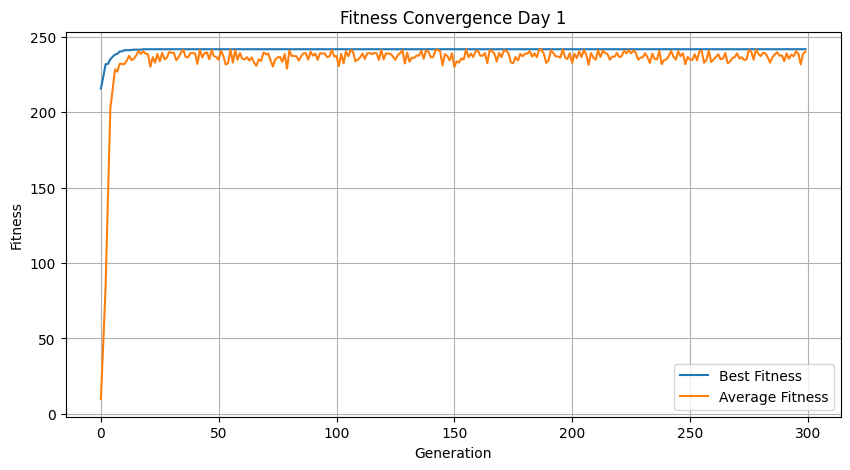

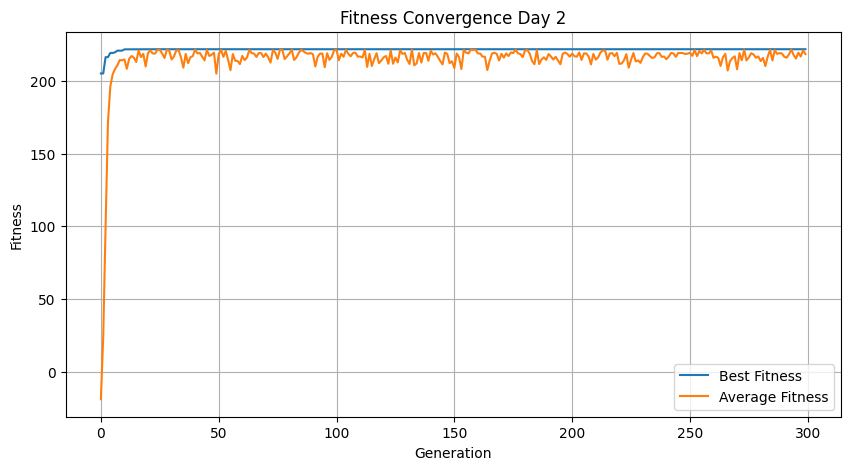

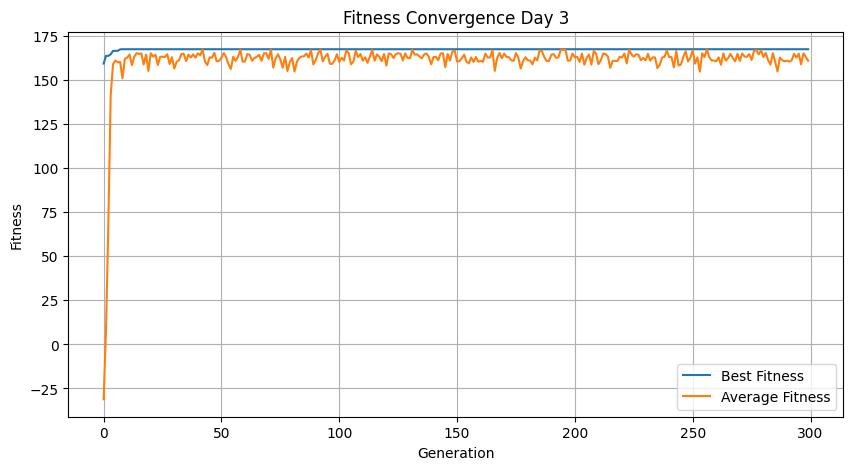

In [27]:
# ==========================================
# FITNESS CONVERGENCE
# ==========================================

for day, result in all_day_results.items():

    plot_convergence(
        result["fitness_history"],
        result["avg_history"],
        day
    )

## 7. Grafik Energy Flow

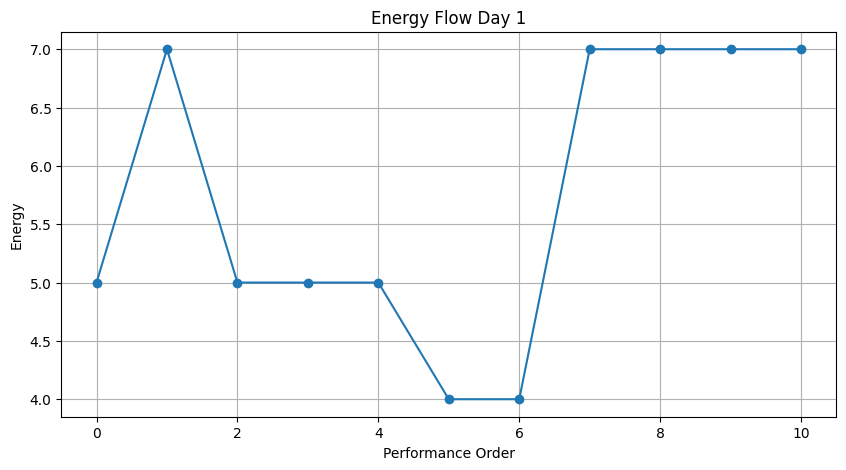

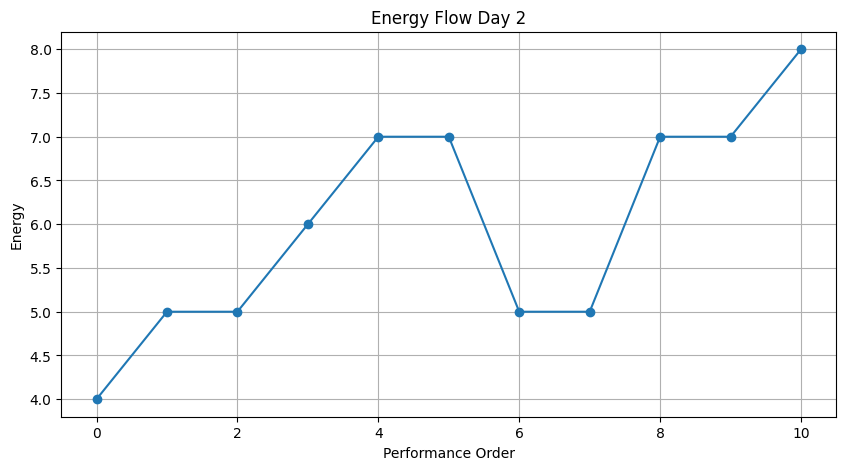

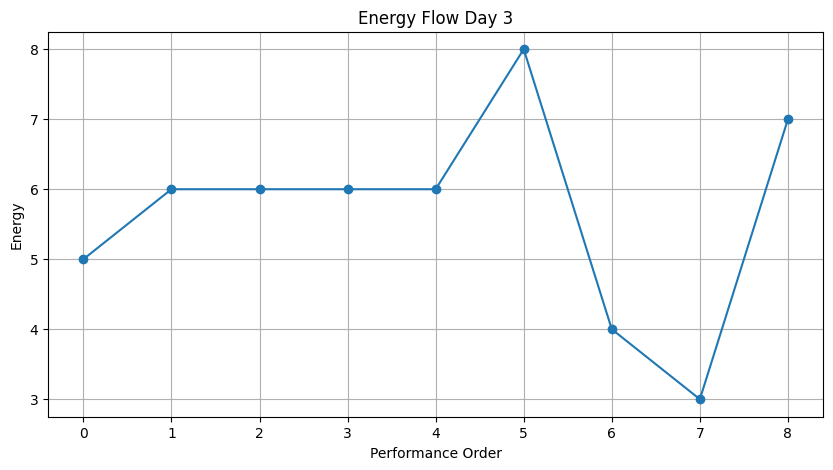

In [28]:
# ==========================================
# ENERGY FLOW
# ==========================================

for day, result in all_day_results.items():

    plot_energy_flow(
        result["best_chrom"],
        result["df_day"],
        day
    )

## 8. Grafik Popularity Placement

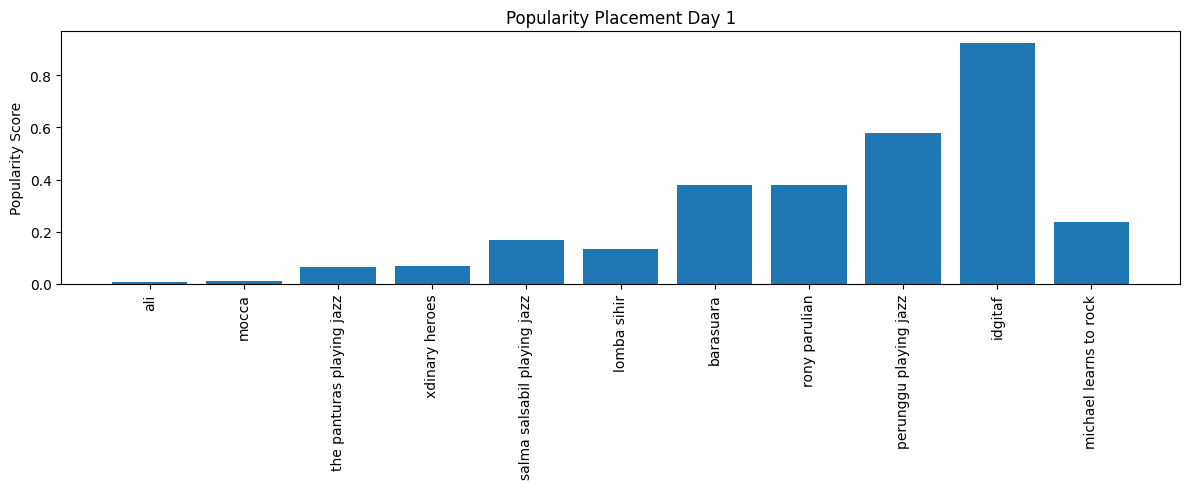

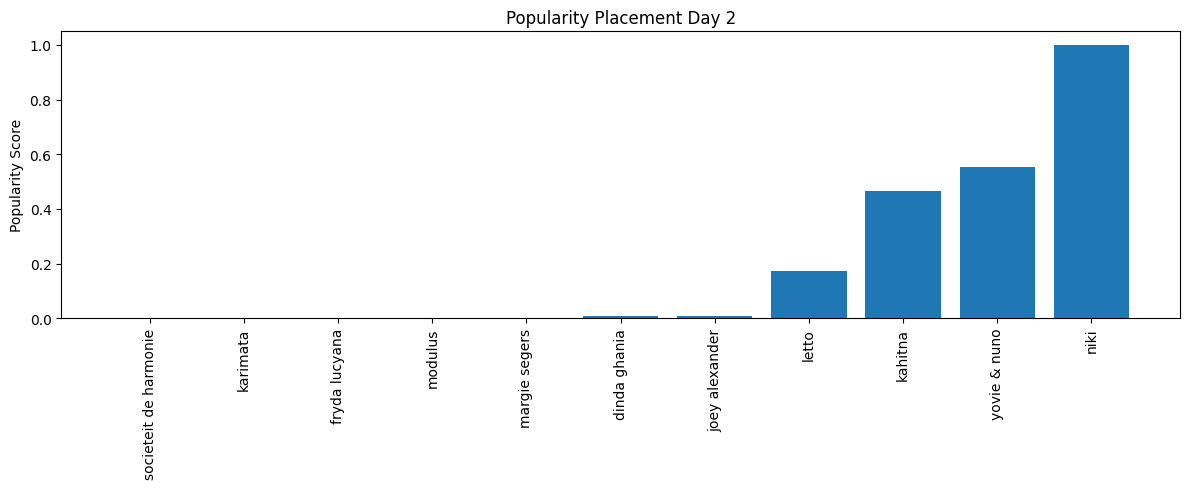

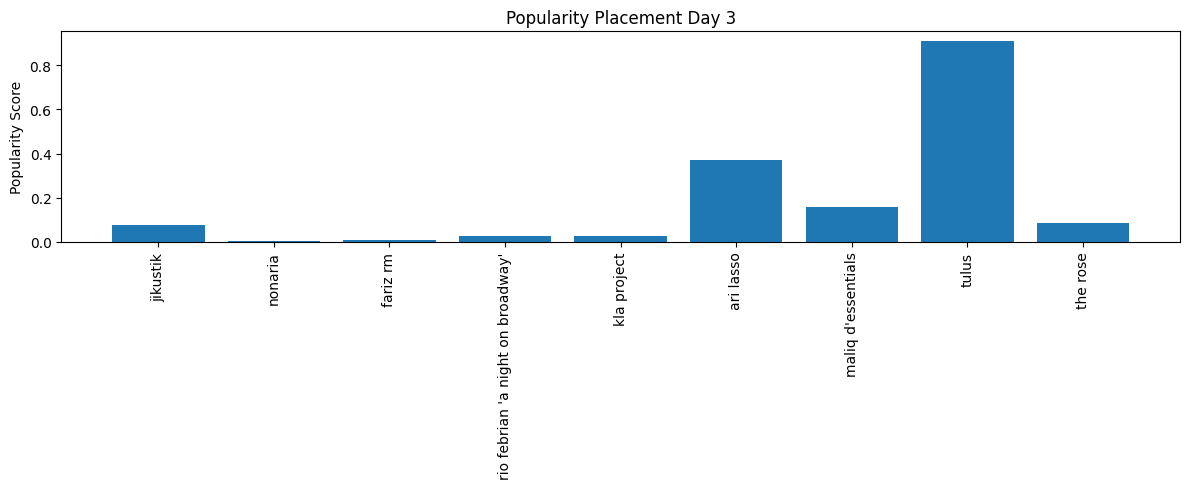

In [29]:
# ==========================================
# POPULARITY PLACEMENT
# ==========================================

for day, result in all_day_results.items():

    plot_popularity_flow(
        result["best_chrom"],
        result["df_day"],
        day
    )

# **EXPORT RESULT**

In [31]:
# ==========================================
# COMBINE RESULT
# ==========================================

all_results = []

for day, result in all_day_results.items():
    lineup_summary = result["lineup_summary"].copy()
    lineup_summary["Day"] = day
    all_results.append(lineup_summary)

final_lineup = pd.concat(
    all_results,
    ignore_index=True
)

# ==========================================
# SAVE CSV
# ==========================================

final_lineup.to_csv(
    "optimized_lineup.csv",
    index=False
)

print("\nFile berhasil disimpan:")
print("optimized_lineup.csv")
display(final_lineup.head())


File berhasil disimpan:
optimized_lineup.csv


,Performance_Order,Artist_name,Genre,Popularity_score,Energy,Tempo,Is_headliner,Day
0,1,ali,indonesian rock,0.007242,5,102.333333,0,1
1,2,mocca,indie pop,0.012551,7,130.000000,0,1
2,3,the panturas playing jazz,surf rock,0.065851,5,109.000000,0,1
3,4,xdinary heroes,k-rock,0.067962,5,107.000000,0,1
4,5,salma salsabil playing jazz,pop,0.167278,5,111.333333,0,1
